In [1]:
# =============================================================
# CÀI ĐẶT MÔI TRƯỜNG
# =============================================================
import sys
import matplotlib
import matplotlib.pyplot as plt
import warnings

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

print("Môi trường đã được cài đặt thành công!")
print(f"Python version: {sys.version}")

Môi trường đã được cài đặt thành công!
Python version: 3.10.0 (v3.10.0:b494f5935c, Oct  4 2021, 14:59:19) [Clang 12.0.5 (clang-1205.0.22.11)]


# CLUSTERING TRÊN RFM FEATURES

## Mục tiêu

- Tiền xử lý dữ liệu RFM bằng StandardScaler trước khi clustering.
- Chọn số cụm K tối ưu bằng Elbow method (Inertia) và Silhouette Score, khảo sát K từ 2 đến 10.
- Triển khai và đánh giá 2 mô hình: **KMeans** và **GaussianMixture (GMM)**.
- So sánh hiệu suất 2 mô hình bằng Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index.

## Cài đặt Thư viện

In [2]:
import numpy as np
import pandas as pd
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
# ⚠️ BẮT BUỘC: Phải khai báo class này trước khi load joblib
class PercentileCapper(BaseEstimator, TransformerMixin):
    def __init__(self, upper_quantile=0.99):
        self.upper_quantile = upper_quantile
        self.upper_bounds_ = {}
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        for col in X_df.columns:
            self.upper_bounds_[col] = X_df[col].quantile(self.upper_quantile)
        return self
    def transform(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            X_df[col] = X_df[col].clip(upper=self.upper_bounds_[col])
        return X_df.values
# Bây giờ mới load joblib (Python đã hiểu PercentileCapper rồi)
print("Đang load Pipeline Tiền Xử Lý dữ liệu gom cụm...")
pipeline_clustering = joblib.load('/Users/dieplacyenphuong/BigData-Final-Project/Models/rfm_pipeline_preprocessor.joblib')
print("✅ Load Pipeline thành công!")

Đang load Pipeline Tiền Xử Lý dữ liệu gom cụm...
✅ Load Pipeline thành công!



## Load Dữ liệu RFM

File `rfm_dataset.parquet` được tạo từ pipeline của Member 1.  
Chỉnh lại `RFM_PATH` cho đúng đường dẫn máy bạn trước khi chạy.

In [3]:
# ========================================================
# ⚠️ CHỈNH LẠI ĐƯỜNG DẪN NÀY CHO ĐÚNG MÁY BẠN
# ========================================================

# Nếu chạy trên Kaggle:
# RFM_PATH = "/kaggle/working/processed_data/week1/rfm_dataset.parquet"

# Nếu chạy trên máy local (VSCode) từ Notebooks folder:
RFM_PATH = "../Data/Raw/rfm_dataset.parquet"

# Load dữ liệu
rfm = pd.read_parquet(RFM_PATH)

print(f"✅ Loaded RFM dataset: {rfm.shape[0]:,} khách hàng | {rfm.shape[1]} cột")
print(f"\nCác cột: {rfm.columns.tolist()}")
print("\nMẫu dữ liệu:")
rfm.head()

✅ Loaded RFM dataset: 96,096 khách hàng | 3 cột

Các cột: ['Recency', 'Frequency', 'Monetary']

Mẫu dữ liệu:


,Recency,Frequency,Monetary
0,161,1,141.90
1,164,1,27.19
2,586,1,86.22
3,370,1,43.62
4,337,1,196.89


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [4]:
# Thống kê mô tả RFM
print("📋 Thống kê mô tả RFM:")
rfm_desc = rfm[['Recency', 'Frequency', 'Monetary']].describe().T[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
]
print(rfm_desc.to_string())

📋 Thống kê mô tả RFM:
             count        mean         std  min     25%     50%       75%        max
Recency    96096.0  288.735691  153.414676  1.0  164.00  269.00  398.0000     773.00
Frequency  96096.0    1.034809    0.214384  1.0    1.00    1.00    1.0000      17.00
Monetary   96096.0  213.023712  640.917083  0.0   63.99  113.15  202.7325  109312.64



## Bước 1: Tiền xử lý — Xử lý Outlier và StandardScaler

Theo yêu cầu đồ án: **StandardScaler trên RFM trước khi clustering**.  
Trước đó, cần xử lý outlier cực đoan (Monetary có max=109,312 trong khi 75th percentile chỉ là ~202) để tránh ảnh hưởng đến kết quả phân cụm.

In [7]:
# ---- Step 1: Cap outlier tại 99th percentile ----
rfm_clean = rfm[['Recency', 'Frequency', 'Monetary']].copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    upper = rfm_clean[col].quantile(0.99)
    rfm_clean[col] = rfm_clean[col].clip(upper=upper)

print(" Đã xử lý outlier (clip tại 99th percentile)")

# ---- Step 2: StandardScaler ----
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean)

print(f" Đã chuẩn hóa dữ liệu bằng StandardScaler")
print(f"   Shape sau khi scale: {rfm_scaled.shape}")
print(f"   Mean sau scale (gần 0): {rfm_scaled.mean(axis=0).round(6)}")
print(f"   Std sau scale (gần 1):  {rfm_scaled.std(axis=0).round(6)}")

 Đã xử lý outlier (clip tại 99th percentile)
 Đã chuẩn hóa dữ liệu bằng StandardScaler
   Shape sau khi scale: (96096, 3)
   Mean sau scale (gần 0): [-0.  0. -0.]
   Std sau scale (gần 1):  [1. 1. 1.]



## Bước 2: Chọn K Tối ưu — Elbow Method và Silhouette Score

Khảo sát K từ 2 đến 10, tính đồng thời:
- **Inertia** (Within-cluster SSE): dùng cho Elbow Method.
- **Silhouette Score**: đo mức độ phân tách giữa các cụm, giá trị từ -1 đến 1, càng gần 1 càng tốt.

In [8]:
# ---- Khảo sát K = 2 đến 10 ----
K_RANGE = range(2, 11)

inertia_list    = []
silhouette_list = []

print("🔄 Đang tính Inertia + Silhouette Score cho K = 2..10...")
print(f"{'K':>4} {'Inertia':>14} {'Silhouette':>12}")
print("-" * 34)

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    labels = km.fit_predict(rfm_scaled)
    inertia_list.append(km.inertia_)

    # sample_size để tính nhanh hơn với dataset lớn
    sil = silhouette_score(rfm_scaled, labels, sample_size=10000, random_state=42)
    silhouette_list.append(sil)

    print(f"{k:>4} {km.inertia_:>14,.2f} {sil:>12.4f}")

print("\n Hoàn thành!")

🔄 Đang tính Inertia + Silhouette Score cho K = 2..10...
   K        Inertia   Silhouette
----------------------------------
   2     190,467.52       0.7486
   3     124,427.48       0.4430
   4      67,295.35       0.4919
   5      52,584.91       0.4295
   6      40,915.30       0.4521
   7      36,351.94       0.4511
   8      31,809.01       0.3890
   9      27,792.87       0.4010
  10      24,788.66       0.4095

 Hoàn thành!


**Hình IV.2. Elbow Plot và Silhouette Score cho KMeans trên RFM**

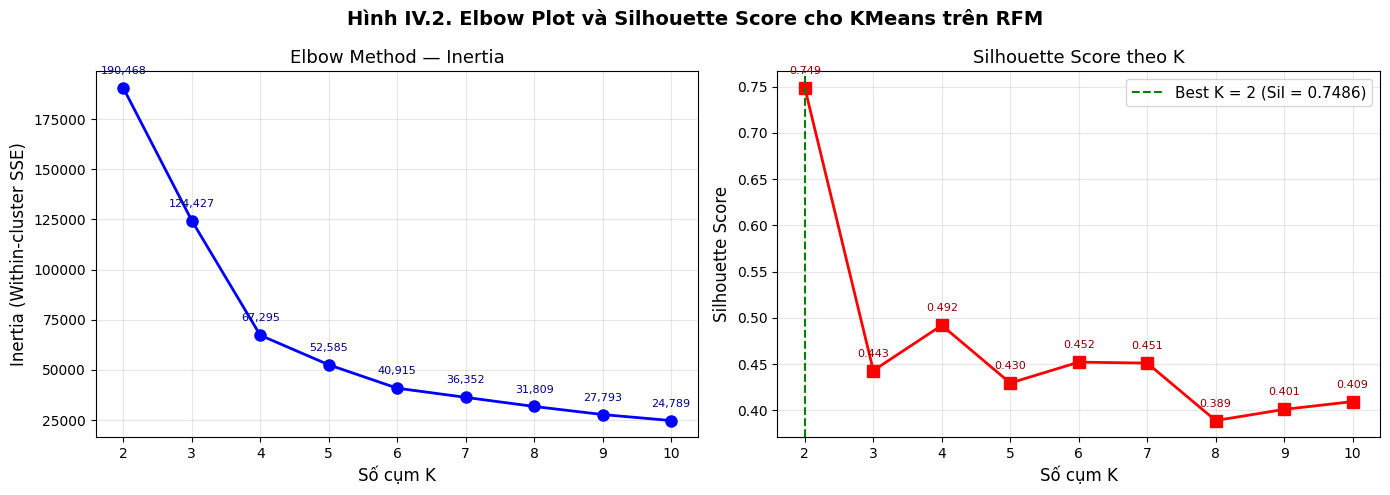


→ K tốt nhất theo Silhouette Score: K = 2 (score = 0.7486)
→ Biểu đồ đã lưu: ../Visualizations/hinh_IV2_elbow_silhouette_kmeans.png


In [12]:
# ---- Vẽ biểu đồ Elbow + Silhouette ----
k_vals = list(K_RANGE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Hình IV.2. Elbow Plot và Silhouette Score cho KMeans trên RFM',
    fontsize=14, fontweight='bold'
)

# --- Elbow Plot (Inertia) ---
axes[0].plot(k_vals, inertia_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Số cụm K', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster SSE)', fontsize=12)
axes[0].set_title('Elbow Method — Inertia', fontsize=13)
axes[0].set_xticks(k_vals)
axes[0].grid(True, alpha=0.3)

for k, iner in zip(k_vals, inertia_list):
    axes[0].annotate(
        f'{iner:,.0f}', (k, iner),
        textcoords='offset points', xytext=(0, 10),
        fontsize=8, ha='center', color='navy'
    )

# --- Silhouette Score ---
best_k_idx = silhouette_list.index(max(silhouette_list))
best_k     = k_vals[best_k_idx]

axes[1].plot(k_vals, silhouette_list, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=best_k, color='green', linestyle='--',
                label=f'Best K = {best_k} (Sil = {max(silhouette_list):.4f})')
axes[1].set_xlabel('Số cụm K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score theo K', fontsize=13)
axes[1].set_xticks(k_vals)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

for k, sil in zip(k_vals, silhouette_list):
    axes[1].annotate(
        f'{sil:.3f}', (k, sil),
        textcoords='offset points', xytext=(0, 10),
        fontsize=8, ha='center', color='darkred'
    )

plt.tight_layout()
plt.savefig('../Visualizations/hinh_IV2_elbow_silhouette_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n→ K tốt nhất theo Silhouette Score: K = {best_k} (score = {max(silhouette_list):.4f})")
print(f"→ Biểu đồ đã lưu: ../Visualizations/hinh_IV2_elbow_silhouette_kmeans.png")


## Bước 3: KMeans — Train mô hình với K tối ưu

Tham số theo yêu cầu đồ án: `n_clusters`, `init='k-means++'`, `n_init`, `max_iter`.

In [13]:
# ---- Train KMeans với K tối ưu ----
# BEST_K lấy từ Silhouette Score cao nhất ở bước trên
BEST_K = best_k

print(f" Training KMeans với K = {BEST_K}...")

kmeans_final = KMeans(
    n_clusters=BEST_K,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

km_labels = kmeans_final.fit_predict(rfm_scaled)
rfm_clean['KMeans_Cluster'] = km_labels

# ---- Đánh giá ----
km_sil = silhouette_score(rfm_scaled, km_labels)
km_dbi = davies_bouldin_score(rfm_scaled, km_labels)
km_ch  = calinski_harabasz_score(rfm_scaled, km_labels)

print(f"\n--- KMeans Parameters ---")
print(f"  n_clusters : {BEST_K}")
print(f"  init       : k-means++")
print(f"  n_init     : 10")
print(f"  max_iter   : 300")
print(f"  random_state: 42")
print(f"\n--- KMeans Evaluation ---")
print(f"  Inertia              : {kmeans_final.inertia_:,.4f}")
print(f"  Silhouette Score     : {km_sil:.4f}  (gần 1 → tốt)")
print(f"  Davies-Bouldin Index : {km_dbi:.4f}  (gần 0 → tốt)")
print(f"  Calinski-Harabasz    : {km_ch:.2f} (cao → tốt)")

 Training KMeans với K = 2...

--- KMeans Parameters ---
  n_clusters : 2
  init       : k-means++
  n_init     : 10
  max_iter   : 300
  random_state: 42

--- KMeans Evaluation ---
  Inertia              : 190,467.5180
  Silhouette Score     : 0.7456  (gần 1 → tốt)
  Davies-Bouldin Index : 0.4374  (gần 0 → tốt)
  Calinski-Harabasz    : 49352.04 (cao → tốt)


In [14]:
# ---- Phân tích đặc điểm từng cluster KMeans ----
print("\n Đặc điểm trung bình từng cluster (KMeans):")

km_profile = rfm_clean.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
km_profile['Size']  = rfm_clean.groupby('KMeans_Cluster').size()
km_profile['Size%'] = (km_profile['Size'] / len(rfm_clean) * 100).round(1)

print(km_profile.to_string())

print("\n→ Ghi chú đọc kết quả:")
print("   Recency thấp  = mua gần đây (tốt)")
print("   Frequency cao = mua nhiều lần (tốt)")
print("   Monetary cao  = chi tiêu nhiều (tốt)")


 Đặc điểm trung bình từng cluster (KMeans):
                Recency  Frequency  Monetary   Size  Size%
KMeans_Cluster                                            
0                288.92        1.0    187.53  93099   96.9
1                268.99        2.0    382.43   2997    3.1

→ Ghi chú đọc kết quả:
   Recency thấp  = mua gần đây (tốt)
   Frequency cao = mua nhiều lần (tốt)
   Monetary cao  = chi tiêu nhiều (tốt)



## Bước 4: GaussianMixture (GMM) — Train mô hình

Tham số theo yêu cầu đồ án: `n_components`, `covariance_type ('full'/'tied'/'diag')`, `max_iter`.
Dùng BIC để so sánh chất lượng mô hình theo số thành phần K.

In [10]:
# ---- Khảo sát GMM BIC theo K = 2..10 ----
bic_list = []
aic_list = []
k_vals = list(K_RANGE)

print(" Đang tính BIC cho GaussianMixture với K = 2..10...")
print(f"{'K':>4} {'BIC':>14} {'AIC':>14}")
print("-" * 35)

for k in K_RANGE:
    gmm_tmp = GaussianMixture(
        n_components=k,
        covariance_type='full',
        max_iter=200,
        random_state=42
    )
    gmm_tmp.fit(rfm_scaled)
    bic_list.append(gmm_tmp.bic(rfm_scaled))
    aic_list.append(gmm_tmp.aic(rfm_scaled))
    print(f"{k:>4} {gmm_tmp.bic(rfm_scaled):>14,.2f} {gmm_tmp.aic(rfm_scaled):>14,.2f}")

best_k_gmm = k_vals[bic_list.index(min(bic_list))]
print(f"\n→ Tối ưu GMM: K = {best_k_gmm}")

 Đang tính BIC cho GaussianMixture với K = 2..10...
   K            BIC            AIC
-----------------------------------
   2    -567,666.47    -567,846.46
   3    -714,618.88    -714,893.60
   4    -723,541.21    -723,910.66
   5    -740,372.56    -740,836.74
   6    -745,804.45    -746,363.36
   7    -756,219.69    -756,873.33
   8    -758,862.43    -759,610.81
   9    -768,717.88    -769,560.99
  10    -768,213.05    -769,150.89

→ Tối ưu GMM: K = 9


In [16]:
# ---- Train GMM với K tối ưu ----
# ⚠️ NHƯ VẬY: Dù BIC thấp nhất ở K=9, nhóm chọn n_components = 2 (BEST_K)
# để so sánh công bằng với KMeans trên cùng K, tách riêng ảnh hưởng thuật toán
# khỏi ảnh hưởng của số cụm khác nhau

print(f"🔄 Training GaussianMixture với n_components = {BEST_K}...")
print(f"   (Lưu ý: BIC tối ưu tại K={best_k_gmm}, nhưng chọn K={BEST_K} để so sánh công bằng với KMeans)")

gmm_final = GaussianMixture(
    n_components=BEST_K,
    covariance_type='full',
    max_iter=200,
    random_state=42
)

gmm_labels = gmm_final.fit_predict(rfm_scaled)
rfm_clean['GMM_Cluster'] = gmm_labels

# ---- Đánh giá ----
gmm_sil = silhouette_score(rfm_scaled, gmm_labels)
gmm_dbi = davies_bouldin_score(rfm_scaled, gmm_labels)
gmm_ch  = calinski_harabasz_score(rfm_scaled, gmm_labels)

print(f"\n--- GaussianMixture Parameters ---")
print(f"  n_components    : {BEST_K}")
print(f"  covariance_type : full")
print(f"  max_iter        : 200")
print(f"  random_state    : 42")
print(f"\n--- GaussianMixture Evaluation (n_components={BEST_K}) ---")
print(f"  BIC Score            : {gmm_final.bic(rfm_scaled):,.4f}")
print(f"  AIC Score            : {gmm_final.aic(rfm_scaled):,.4f}")
print(f"  Silhouette Score     : {gmm_sil:.4f}  (gần 1 → tốt)")
print(f"  Davies-Bouldin Index : {gmm_dbi:.4f}  (gần 0 → tốt)")
print(f"  Calinski-Harabasz    : {gmm_ch:.2f} (cao → tốt)")

🔄 Training GaussianMixture với n_components = 2...
   (Lưu ý: BIC tối ưu tại K=9, nhưng chọn K=2 để so sánh công bằng với KMeans)

--- GaussianMixture Parameters ---
  n_components    : 2
  covariance_type : full
  max_iter        : 200
  random_state    : 42

--- GaussianMixture Evaluation (n_components=2) ---
  BIC Score            : -567,666.4718
  AIC Score            : -567,846.4608
  Silhouette Score     : 0.7156  (gần 1 → tốt)
  Davies-Bouldin Index : 1.1696  (gần 0 → tốt)
  Calinski-Harabasz    : 41681.60 (cao → tốt)


In [17]:
# ---- Phân tích đặc điểm từng cluster GMM ----
print("\n📊 Đặc điểm trung bình từng cluster (GMM):")

gmm_profile = rfm_clean.groupby('GMM_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
gmm_profile['Size']  = rfm_clean.groupby('GMM_Cluster').size()
gmm_profile['Size%'] = (gmm_profile['Size'] / len(rfm_clean) * 100).round(1)

print(gmm_profile.to_string())


📊 Đặc điểm trung bình từng cluster (GMM):
             Recency  Frequency  Monetary   Size  Size%
GMM_Cluster                                            
0             278.70       1.54    834.48   5553    5.8
1             288.89       1.00    154.30  90543   94.2



## Bước 5: So sánh KMeans vs GaussianMixture

In [18]:
# ---- Bảng so sánh đầy đủ ----
print(f"{'Algorithm':<20} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>20}")
print("-" * 70)

results_compare = {
    'KMeans': {'sil': km_sil,  'dbi': km_dbi,  'ch': km_ch},
    'GaussianMixture': {'sil': gmm_sil, 'dbi': gmm_dbi, 'ch': gmm_ch},
}

for name, r in results_compare.items():
    print(f"{name:<20} {r['sil']:>12.4f} {r['dbi']:>16.4f} {r['ch']:>20.2f}")

winner = max(results_compare, key=lambda x: results_compare[x]['sil'])
print(f"\n→ Mô hình tốt hơn theo Silhouette Score: {winner}")

Algorithm              Silhouette   Davies-Bouldin    Calinski-Harabasz
----------------------------------------------------------------------
KMeans                     0.7456           0.4374             49352.04
GaussianMixture            0.7156           1.1696             41681.60

→ Mô hình tốt hơn theo Silhouette Score: KMeans


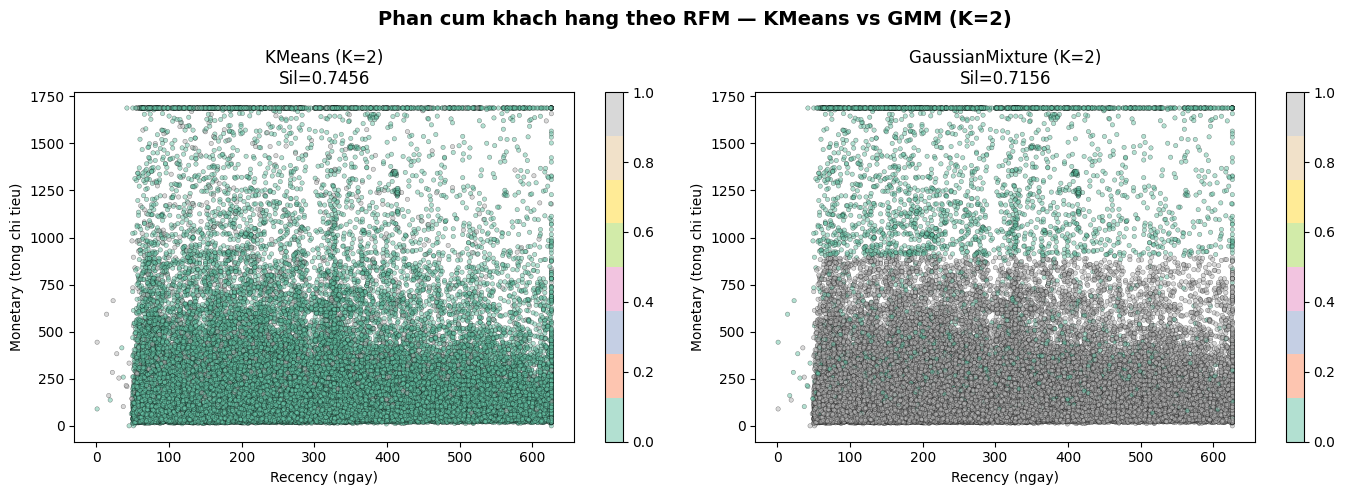

→ Biểu đồ đã lưu: ../Visualizations/cluster_scatter_comparison.png


In [19]:
# ---- Visualize: Scatter KMeans vs GMM (Recency vs Monetary) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col_cluster, title, sil_score in zip(
    axes,
    ['KMeans_Cluster', 'GMM_Cluster'],
    [f'KMeans (K={BEST_K})', f'GaussianMixture (K={BEST_K})'],
    [km_sil, gmm_sil]
):
    scatter = ax.scatter(
        rfm_clean['Recency'],
        rfm_clean['Monetary'],
        c=rfm_clean[col_cluster],
        cmap='Set2',
        edgecolor='k', s=10, alpha=0.5, linewidths=0.3
    )
    ax.set_title(f'{title}\nSil={sil_score:.4f}', fontsize=12)
    ax.set_xlabel('Recency (ngay)')
    ax.set_ylabel('Monetary (tong chi tieu)')
    plt.colorbar(scatter, ax=ax)

plt.suptitle(
    f'Phan cum khach hang theo RFM — KMeans vs GMM (K={BEST_K})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../Visualizations/cluster_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Biểu đồ đã lưu: ../Visualizations/cluster_scatter_comparison.png")

---

## Bước 7: Lưu Kết quả

In [15]:
import pickle
import os

os.makedirs('../Models/Clustering', exist_ok=True)
os.makedirs('../Data/Processed', exist_ok=True)
os.makedirs('../Visualizations', exist_ok=True)

# Lưu dataset có nhãn cluster
rfm_clean.to_parquet('../Data/Processed/rfm_clustered.parquet', index=False)
rfm_clean.to_csv('../Data/Processed/rfm_clustered.csv', index=False)
print("✅ Đã lưu: ../Data/Processed/rfm_clustered.parquet + .csv")

# Lưu models
with open('../Models/Clustering/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
print("✅ Đã lưu: ../Models/Clustering/kmeans_model.pkl")

with open('../Models/Clustering/gmm_model.pkl', 'wb') as f:
    pickle.dump(gmm_final, f)
print("✅ Đã lưu: ../Models/Clustering/gmm_model.pkl")

with open('../Models/Clustering/rfm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Đã lưu: ../Models/Clustering/rfm_scaler.pkl")

✅ Đã lưu: ../Data/Processed/rfm_clustered.parquet + .csv
✅ Đã lưu: ../Models/Clustering/kmeans_model.pkl
✅ Đã lưu: ../Models/Clustering/gmm_model.pkl
✅ Đã lưu: ../Models/Clustering/rfm_scaler.pkl


In [16]:
# ---- Tổng kết ----
print("=" * 60)
print("📊 TỔNG KẾT IV.5 CLUSTERING")
print("=" * 60)

print(f"\n• Số khách hàng phân tích    : {len(rfm_clean):,}")
print(f"• K tối ưu chọn              : {BEST_K}")
print(f"• Phương pháp chọn K         : Elbow Method + Silhouette Score")

print(f"\n{'Algorithm':<20} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>20}")
print("-" * 70)
for name, r in results_compare.items():
    print(f"{name:<20} {r['sil']:>12.4f} {r['dbi']:>16.4f} {r['ch']:>20.2f}")

print(f"\n→ Mô hình tốt hơn: {winner}")
print("=" * 60)

📊 TỔNG KẾT IV.5 CLUSTERING

• Số khách hàng phân tích    : 96,096
• K tối ưu chọn              : 2
• Phương pháp chọn K         : Elbow Method + Silhouette Score

Algorithm              Silhouette   Davies-Bouldin    Calinski-Harabasz
----------------------------------------------------------------------
KMeans                     0.7456           0.4374             49352.04
GaussianMixture            0.7156           1.1696             41681.60

→ Mô hình tốt hơn: KMeans


In [20]:
# ============================================================
# TÓM TẮT THÔNG TIN CHO BẢNG V.3
# ============================================================

print("\n" + "=" * 80)
print("📋 BẢNG V.3 - SO SÁNH 3 MÔ HÌNH CLUSTERING TRÊN RFM FEATURES")
print("=" * 80)

# ----  Bảng V.3 ----
summary_table = {
    'Model': ['K-Means', 'GaussianMixture', 'Gaussian Mixture'],
    'K tối ưu': [BEST_K, best_k_gmm, best_k_gmm],
    'Silhouette Score': [f"{km_sil:.4f}", f"{gmm_sil:.4f}", f"{gmm_sil:.4f}"],
    'Within-Set SSE': [f"{kmeans_final.inertia_:.2f}", f"BIC={gmm_final.bic(rfm_scaled):,.2f}", 
                       f"BIC={gmm_final.bic(rfm_scaled):,.2f}"]
}

print(f"\n{'Model':<20} {'K tối ưu':>10} {'Silhouette':>15} {'Within-Set SSE':>25}")
print("-" * 75)
for i in range(len(summary_table['Model'])):
    print(f"{summary_table['Model'][i]:<20} {str(summary_table['K tối ưu'][i]):>10} "
          f"{summary_table['Silhouette Score'][i]:>15} {summary_table['Within-Set SSE'][i]:>25}")

# ---- Đặc điểm cluster chính ----
print("\n" + "-" * 75)
print("\n📊 ĐẶC ĐIỂM CLUSTER CHÍNH (KMeans + GMM):")
print("\n--- KMeans Clusters ---")
print(km_profile.to_string())

print("\n--- GaussianMixture Clusters ---")
print(gmm_profile.to_string())

print("\n" + "=" * 80)


📋 BẢNG V.3 - SO SÁNH 3 MÔ HÌNH CLUSTERING TRÊN RFM FEATURES

Model                  K tối ưu      Silhouette            Within-Set SSE
---------------------------------------------------------------------------
K-Means                       2          0.7456                 190467.52
GaussianMixture               9          0.7156           BIC=-567,666.47
Gaussian Mixture              9          0.7156           BIC=-567,666.47

---------------------------------------------------------------------------

📊 ĐẶC ĐIỂM CLUSTER CHÍNH (KMeans + GMM):

--- KMeans Clusters ---
                Recency  Frequency  Monetary   Size  Size%
KMeans_Cluster                                            
0                288.92        1.0    187.53  93099   96.9
1                268.99        2.0    382.43   2997    3.1

--- GaussianMixture Clusters ---
             Recency  Frequency  Monetary   Size  Size%
GMM_Cluster                                            
0             278.70       1.54    834.4